# Analysis of Median and Performancee Spread evolution from 2001-05 to 2021-25

#### Imports and Data Loading

In [1]:
import sys
from pathlib import Path

parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import util
import plotting.plotting_style as plt
import pandas as pd
import numpy as np
import seaborn as sns
import help_functions as hp
from plotting.plotting_style import rgb
from scipy import stats


# Manual path, automatic did not work
# data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\final_data_iaaf_scores_neu_v2.csv')
data = util.load_data() 

data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,group
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211,Sprint
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187,Sprint
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169,Sprint
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148,Sprint
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146,Sprint


#### Data Preparation

In [2]:
# Defining Age Groups
data['altersklasse'] = data['altersklasse'].replace({'Maenner': 'Adult', 'Frauen': 'Adult', '18': 'U18', '20': 'U20'})

# Get Data for Analysis, top 35, exclude U23
summary = data.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).size().reset_index(name='anzahl')
under = summary[(summary['altersklasse'] == 'U23') | (summary['anzahl'] < 35)]
under = under.sort_values(by=['jahr', 'altersklasse', 'geschlecht', 'disziplin'])
data_all = data.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).filter(lambda x: x.name[1] != 'U23' and len(x) >= 35)

# Exclude changes in weights/heights in 2001
u20_changes = ['Kugelstoss', 'Hammerwurf', 'Diskuswurf', '110 m Huerden']
mask_u20_2001 = (data_all['altersklasse'] == 'U20') & \
                (data_all['disziplin'].isin(u20_changes)) & \
                (data_all['jahr'] == 2001)

data_all = data_all[~mask_u20_2001]

# Make sure getting all Data
data_all = data_all.sort_values(by='iaaf_score', ascending=False)
data_all = data_all.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).head(35)

data['altersklasse'].unique()

array(['Adult', 'U18', 'U20', 'U23'], dtype=object)

#### Median, Performance Gap und Signifikanztests

In [3]:

def get_anaysis_data(df, group_cols, start_period=(2001, 2005), end_period=(2021, 2025)):
    results = []
    
    grouped = df.groupby(group_cols) if group_cols else [("Global", df)]

    for names, subgroup in grouped:

        current_group = subgroup['group'].iloc[0]
        
        # Performance Gap
        def get_period_pool(data, years):
            period_data = data[data["jahr"].between(*years)]
            
            top_pool = (period_data.groupby("jahr")["iaaf_score"].nlargest(3).reset_index(drop=True))
            
            low_pool = (period_data.groupby("jahr")["iaaf_score"].nsmallest(3).reset_index(drop=True))
            
            return top_pool, low_pool

        s_top, s_low = get_period_pool(subgroup, start_period)
        e_top, e_low = get_period_pool(subgroup, end_period)

        s_pool = subgroup[subgroup["jahr"].between(*start_period)]["iaaf_score"].dropna()
        e_pool = subgroup[subgroup["jahr"].between(*end_period)]["iaaf_score"].dropna()

        if len(s_top) > 1 and len(e_top) > 1 and len(s_low) > 1 and len(e_low) > 1:
            # Mann-Whitney-U-Test for median comparison
            u_stat, p_median = stats.mannwhitneyu(e_pool, s_pool, alternative='two-sided')

            # Medians
            med_e, med_s = np.median(e_pool), np.median(s_pool)

            # Effect size r
            n_total = len(e_pool) + len(s_pool)
            z_score = stats.norm.ppf(p_median / 2) # approximation
            r_effect = abs(z_score) / np.sqrt(n_total)

            m_diff_perc = (med_e - med_s) / med_s * 100

            # Performance Gap
            gap_s = s_top.mean() - s_low.mean()
            gap_e = e_top.mean() - e_low.mean()

            top_3_avg_s = s_top.mean()
            low_3_avg_s = s_low.mean()
            top_3_avg_e = e_top.mean()
            low_3_avg_e = e_low.mean()

            obs_diff = gap_e - gap_s

            # Bootstrap
            boot_diffs = []
            for _ in range(10000):
                # Resampling 
                s_top_res = np.random.choice(s_top, size=len(s_top), replace=True).mean()
                s_low_res = np.random.choice(s_low, size=len(s_low), replace=True).mean()
                e_top_res = np.random.choice(e_top, size=len(e_top), replace=True).mean()
                e_low_res = np.random.choice(e_low, size=len(e_low), replace=True).mean()
                
                boot_diffs.append((e_top_res - e_low_res) - (s_top_res - s_low_res))
            
            boot_diffs = np.array(boot_diffs)
            ci_low = np.percentile(boot_diffs, 2.5)
            ci_high = np.percentile(boot_diffs, 97.5)

            std_boot = np.std(boot_diffs)
            effect_size_d = obs_diff / std_boot if std_boot != 0 else 0
            
            # P-value for the gap
            p_gap = np.mean(np.abs(boot_diffs - np.mean(boot_diffs)) >= np.abs(obs_diff))

            # Gap difference percentage
            gap_diff_perc = ((gap_e - gap_s) / gap_s * 100) if gap_s > 0 else 0

            res = {col: val for col, val in zip(group_cols, names)} if group_cols else {"Group": "Global"}
            res.update({
                "Median_Start": round(med_s, 2),
                "Median_End": round(med_e, 2),
                "Median_Diff_Abs": round((med_e - med_s), 2),
                "Median_Diff_%": round(m_diff_perc, 2),
                "P_Val_MWU": round(p_median, 4),
                "MWU_sig": "Yes" if p_median < 0.05 else "No",
                "Effect_r": round(r_effect, 3),
                "Gap_Start": round(gap_s, 2),
                "Gap_Start_top3_avg": round(top_3_avg_s, 2),
                "Gap_Start_low3_avg": round(low_3_avg_s, 2),
                "Gap_End": round(gap_e, 2),
                "Gap_End_top3_avg": round(top_3_avg_e, 2),
                "Gap_End_low3_avg": round(low_3_avg_e, 2),
                "Gap_Diff_Abs": round(obs_diff, 2),
                "Gap_Diff_%": round(gap_diff_perc, 2),
                "Gap_CI_Lower": round(ci_low, 2),
                "Gap_CI_Upper": round(ci_high, 2),
                "Gap_Sig_Bootstrap": "Yes" if ci_low > 0 or ci_high < 0 else "No",
                "Gap_Effect_Size": round(effect_size_d, 3),
                "group": current_group
            })
            results.append(res)

    return pd.DataFrame(results)

analysis_results = get_anaysis_data(data_all, group_cols=['altersklasse', 'geschlecht', 'disziplin'])
print(analysis_results['altersklasse'].unique())
analysis_results.head()

['Adult' 'U18' 'U20']


,altersklasse,geschlecht,disziplin,Median_Start,Median_End,Median_Diff_Abs,Median_Diff_%,P_Val_MWU,MWU_sig,Effect_r,...,Gap_End,Gap_End_top3_avg,Gap_End_low3_avg,Gap_Diff_Abs,Gap_Diff_%,Gap_CI_Lower,Gap_CI_Upper,Gap_Sig_Bootstrap,Gap_Effect_Size,group
0,Adult,M,10 000 m,896.0,961.0,65.0,7.25,0.0,Yes,0.347,...,277.53,1140.60,863.07,86.40,45.20,52.87,118.00,Yes,5.212,Run
1,Adult,M,10 km,942.0,991.0,49.0,5.20,0.0,Yes,0.427,...,165.58,1107.00,941.42,25.45,18.16,3.95,46.88,Yes,2.317,Run
2,Adult,M,100 m,1008.0,1076.0,68.0,6.75,0.0,Yes,0.602,...,140.87,1175.73,1034.87,-11.67,-7.65,-27.00,3.20,No,-1.509,Sprint
3,Adult,M,110 m Huerden,1012.0,979.0,-33.0,-3.26,0.0,Yes,0.306,...,225.73,1128.00,902.27,26.60,13.36,8.33,44.47,Yes,2.873,Sprint
4,Adult,M,1500 m,1029.0,1062.0,33.0,3.21,0.0,Yes,0.368,...,166.87,1180.00,1013.13,27.87,20.05,8.87,47.53,Yes,2.825,Run


In [4]:
# Changes on 2012/13 - we include them in the Gap analysis, but not median analysis
u18_regelaenderung = [
    ('U18', 'W', 'Kugelstoss'),
    ('U18', 'W', 'Hammerwurf'),
    ('U18', 'W', 'Speerwurf'),
    ('U18', 'M', 'Kugelstoss'),
    ('U18', 'M', 'Hammerwurf')
]

analysis_results['Marker'] = 'normal'
mask = analysis_results[['altersklasse', 'geschlecht', 'disziplin']].apply(tuple, axis=1).isin(u18_regelaenderung)
analysis_results.loc[mask, 'Marker'] = 'Regeländerung'

analysis_results['Label'] = analysis_results['disziplin']
analysis_results.loc[mask, 'Label'] = analysis_results['disziplin'] + '*'

cols_to_null = ['Median_Start', 'Median_End', 'Median_Diff_Abs', 'Median_Diff_%', 'P_Val_MWU']
analysis_results.loc[mask, cols_to_null] = np.nan

print(analysis_results[analysis_results['Marker'] == 'Regeländerung'])



   altersklasse geschlecht   disziplin  Median_Start  Median_End  \
50          U18          M  Hammerwurf           NaN         NaN   
52          U18          M  Kugelstoss           NaN         NaN   
66          U18          W  Hammerwurf           NaN         NaN   
68          U18          W  Kugelstoss           NaN         NaN   
69          U18          W   Speerwurf           NaN         NaN   

    Median_Diff_Abs  Median_Diff_%  P_Val_MWU MWU_sig  Effect_r  ...  \
50              NaN            NaN        NaN     Yes     0.371  ...   
52              NaN            NaN        NaN     Yes     0.439  ...   
66              NaN            NaN        NaN     Yes     0.617  ...   
68              NaN            NaN        NaN     Yes     0.657  ...   
69              NaN            NaN        NaN     Yes     0.248  ...   

    Gap_End_low3_avg  Gap_Diff_Abs  Gap_Diff_%  Gap_CI_Lower  Gap_CI_Upper  \
50            581.73         73.33       21.50         28.13        119.40   
52

#### Plot of Median against Performance Spread

['Adult', 'U20', 'U18']
Plotting Regeländerung for U18, M
Plotting Regeländerung for U18, W


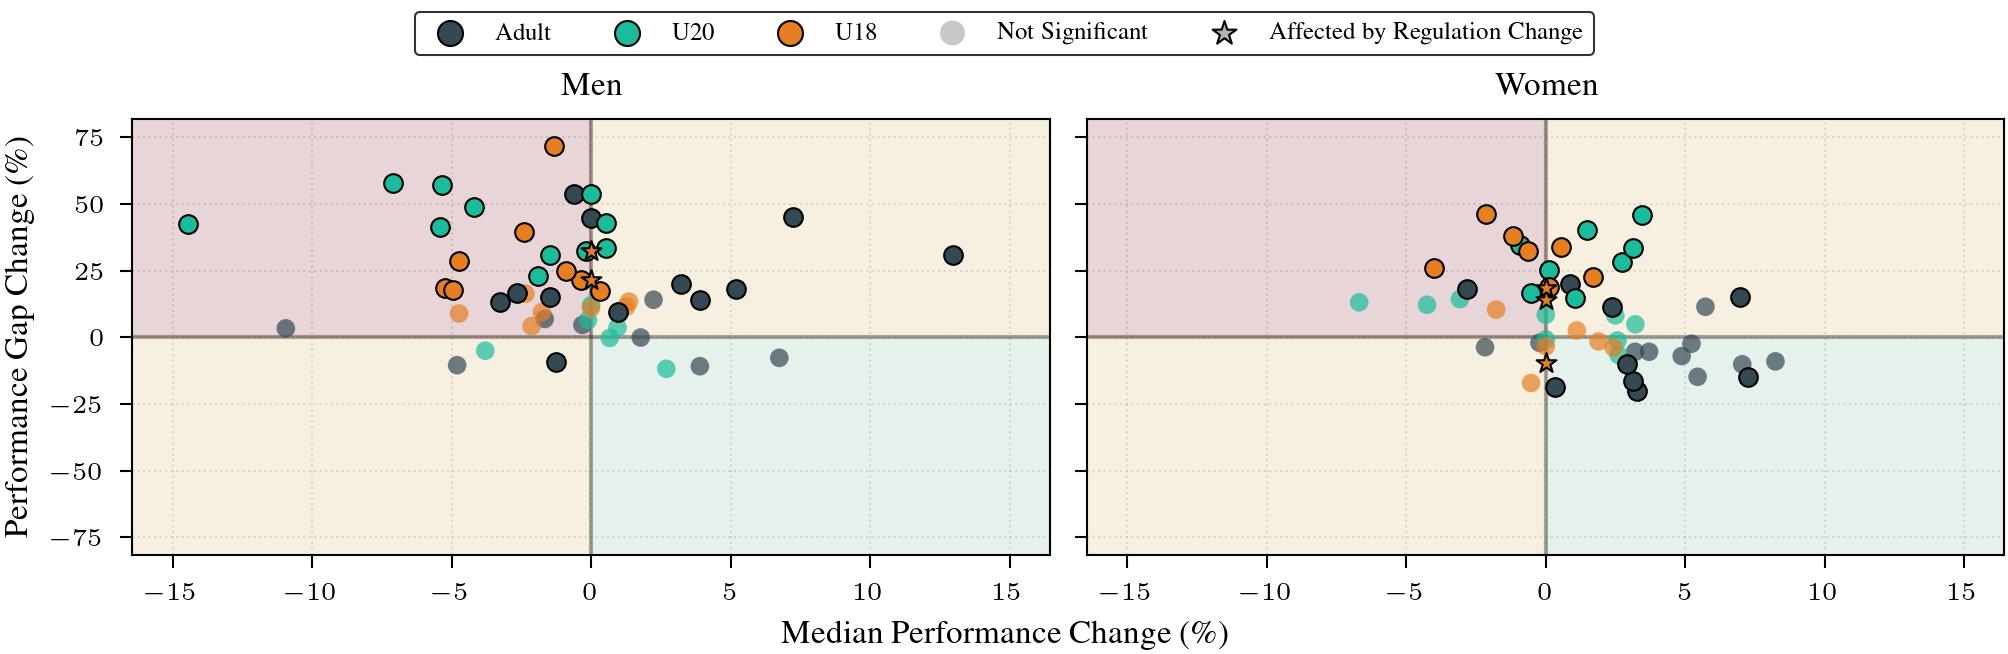

In [16]:
plot_data = analysis_results.copy()


def get_point_colors(subset, gender_color):
    face_colors = []
    edge_colors = []
    linewidths = []
    
    for _, row in subset.iterrows():
        # check if change
        if (row['altersklasse'], row['geschlecht'], row['disziplin']) in u18_regelaenderung:
            face_colors.append('#d3d3d3')
            edge_colors.append(gender_color) 
            linewidths.append(2.5) 
        else:
            # Normal colors
            face_colors.append(gender_color)
            edge_colors.append('none')
            linewidths.append(0)
            
    return face_colors, edge_colors, linewidths

# colors = {'M': "#c8564a", 'W': "#5e6be1"} 
# edge_colors = {'M': "blue", 'W': "red"} 
# colors = {'M': plt.rgb.tue_blue, 'W': plt.rgb.tue_red}
colors = {'Adult': "#344953", "U20": "#1abc9c", "U18": "#e67e22"}
labels = {'M': 'Men', 'W': 'Women'}

unique_ages = sorted(plot_data['altersklasse'].unique(), key=lambda x: ['Adult', 'U20', 'U18'].index(x))
print(unique_ages)
marker_styles = ['o', 's', 'D', 'v'] 
marker_map = {age: marker_styles[i] for i, age in enumerate(unique_ages)}

x_limit = max(abs(plot_data["Median_Diff_%"].min()), abs(plot_data["Median_Diff_%"].max())) + 2
y_limit = max(abs(plot_data["Gap_Diff_%"].min()), abs(plot_data["Gap_Diff_%"].max())) + 10

with plt.rc_context(plt.bundles.icml2024(column="full", ncols=2, nrows=1)):
    fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True)

    # Scatter Plot
    for i, gender in enumerate(['M', 'W']):
        ax = axes[i]
        if gender not in plot_data['geschlecht'].unique():
            continue

        ax.fill_between([0, x_limit], -y_limit, 0, color=plt.rgb.tue_lightgreen, alpha=0.2) # Gut
        ax.fill_between([-x_limit, 0], 0, y_limit, color=plt.rgb.tue_red, alpha=0.2)   # Schlecht
        # ax.fill_between([0, x_limit], 0, y_limit, color=plt.rgb.tue_gray, alpha=0.2) # Gemischt
        # ax.fill_between([-x_limit, 0], -y_limit, 0, color=plt.rgb.tue_gray, alpha=0.2) # Gemischt
        ax.fill_between([0, x_limit], 0, y_limit, color=plt.rgb.tue_lightorange, alpha=0.2) # Gemischt
        ax.fill_between([-x_limit, 0], -y_limit, 0, color=plt.rgb.tue_lightorange, alpha=0.2) # Gemisc

        # ax.scatter([], [], color=colors[gender], alpha=0.9)
        
        for age in unique_ages:
            # mask = (plot_data['geschlecht'] == gender) & (plot_data['altersklasse'] == age)
            # subset = plot_data[mask]
            subset = plot_data[(plot_data['geschlecht'] == gender) & (plot_data['altersklasse'] == age)]
            
            if subset.empty:
                continue

            f_color = colors[age]
            edge_color = 'black'

            # Regulation Change
            mask_reg_change = subset['Marker'] == 'Regeländerung'
            sub_reg_change = subset[mask_reg_change]
            if not sub_reg_change.empty:
                print(f"Plotting Regeländerung for {age}, {gender}")
                ax.scatter(
                    [0] * len(sub_reg_change["Gap_Diff_%"]), sub_reg_change["Gap_Diff_%"], 
                    facecolors=f_color, edgecolors='black',
                    marker='*', alpha=1, zorder=5, s=25
                )
                # continue



            # Not significant
            mask_no = subset['Gap_Sig_Bootstrap'] == 'No'
            sub_no = subset[mask_no]
            if not sub_no.empty:
                # f_cols, e_cols, l_widths = get_point_colors(sub_no, colors[gender])
                ax.scatter(
                    sub_no["Median_Diff_%"], sub_no["Gap_Diff_%"], 
                    facecolors=f_color, edgecolors='none',
                    marker='o', alpha=0.7, zorder=3, s=20
                )

            # Significant
            mask_yes = subset['Gap_Sig_Bootstrap'] == 'Yes'
            sub_yes = subset[mask_yes]
            if not sub_yes.empty:
                # f_cols, e_cols, l_widths = get_point_colors(sub_yes, colors[gender])
                ax.scatter(
                    sub_yes["Median_Diff_%"], sub_yes["Gap_Diff_%"], 
                    facecolors=f_color, edgecolors=edge_color,
                    marker='o', alpha=1, zorder=4, s=20
                )

        for age in unique_ages:
            ax.scatter([], [], facecolor=colors[age], marker='o', 
                    label=age, edgecolors='black')
            
        ax.scatter(
            [], [],
            facecolors=plt.rgb.tue_gray, edgecolors='none',
            marker='o', alpha=0.7, zorder=3, label='Not Significant'
        )
            
        ax.scatter([], [], facecolors=plt.rgb.tue_gray, edgecolors='black', 
                marker='*', label='Affected by Regulation Change')

        # Reference Lines
        ax.axvline(0, color='black', linestyle='-', alpha=0.3, zorder=2)
        ax.axhline(0, color='black', linestyle='-', alpha=0.3, zorder=2)

        # Limits
        ax.set_xlim(-x_limit, x_limit)
        

        ax.set_title(labels[gender])
        ax.grid(True, linestyle=':', alpha=0.4, zorder=0)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncols=5)
    axes[0].set_ylabel("Performance Gap Change (\\%)")
    fig.text(0.5, -0.04, 'Median Performance Change (\\%)', ha='center')
    axes[0].set_ylim(-y_limit, y_limit)

    plt.savefig("gap_performance_change", category="Gap Analysis")
    plt.show()

Some interesting numbers of the plot

In [6]:
#TODO

# Analysis per Rank

Exclude the data, where 2012/13 change in weights

In [7]:
data_ranks_clean = data_all.copy()

u18_wurf_exclude = [
    ('U18', 'W', 'Kugelstoss'), ('U18', 'W', 'Hammerwurf'), ('U18', 'W', 'Speerwurf'),
    ('U18', 'M', 'Kugelstoss'), ('U18', 'M', 'Hammerwurf')
]

mask_u18_wurf = data_ranks_clean[['altersklasse', 'geschlecht', 'disziplin']].apply(tuple, axis=1).isin(u18_wurf_exclude)
data_ranks_clean = data_ranks_clean[~mask_u18_wurf]

data_ranks_clean['rank'] = data_ranks_clean.groupby(["jahr", "disziplin", "geschlecht", "altersklasse"])["iaaf_score"].rank(ascending=False, method='first')

Calculate Rank Means

In [8]:
def calculate_rank_diff(df, group_cols=None, num_entries=35):
    """
    Calculates the median IAAF score for the baseline and end periods 
    across the whole group per rank, then computes the % difference.
    """
    # 1. Define time periods
    df_start = df[df["jahr"].between(2001, 2005)].copy()
    df_end = df[df["jahr"].between(2021, 2025)].copy()
    
    # 2. Define how to group (always include rank)
    agg_cols = (group_cols if group_cols else []) + ["rank"]
    
    # 3. Calculate collective Medians for both periods
    # This treats the group (e.g., "Run" or "Global") as one single distribution
    median_start = df_start.groupby(agg_cols)["iaaf_score"].mean().reset_index()
    median_end = df_end.groupby(agg_cols)["iaaf_score"].mean().reset_index()
    
    # 4. Merge the two periods
    final = pd.merge(
        median_start, median_end, 
        on=agg_cols, 
        suffixes=('_start', '_end')
    )
    
    # 5. Calculate the single % Difference
    final["mean_diff_perc"] = (
        (final["iaaf_score_end"] - final["iaaf_score_start"]) / 
        final["iaaf_score_start"] * 100
    )
    
    return final

# rank
results_ranks_age      = calculate_rank_diff(data_ranks_clean, ["geschlecht", "altersklasse"], 35)
results_ranks_all      = calculate_rank_diff(data_ranks_clean, [], 35) # Leere Liste für "All"

Plot Ranks against change from 2001-05 to 2021-25

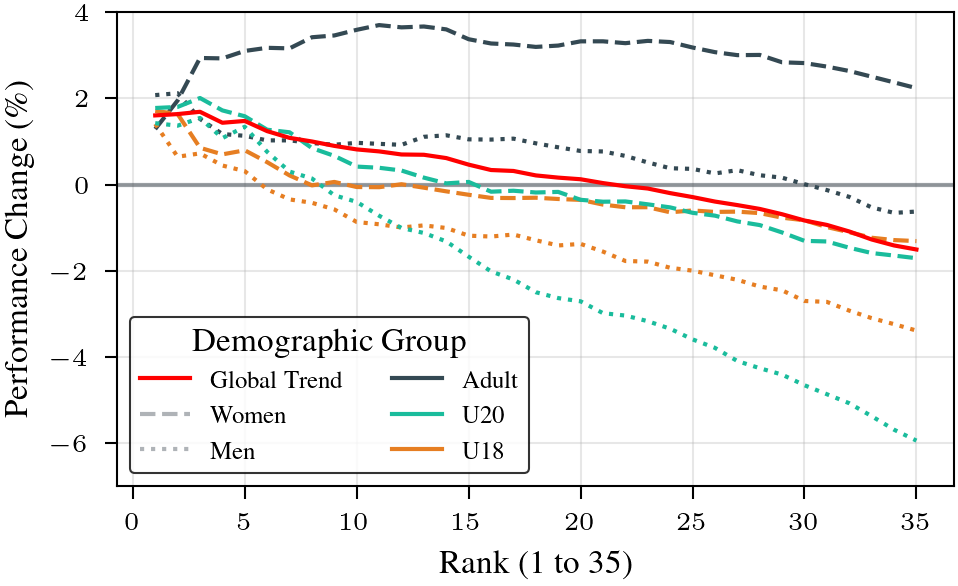

In [17]:

# 1. Setup the Plot

# 2. Define Age-specific colors (Consistent across genders)
# Blues/Dark tones for a professional look
colors = {'Adult': "#344953", "U20": "#1abc9c", "U18": "#e67e22"}

with plt.rc_context(plt.bundles.icml2024(column="half")):
# We use Solid for Women and Dashed for Men (or vice versa)
    for (age, gender), group_df in results_ranks_age.groupby(["altersklasse", "geschlecht"]):
        color = colors.get(age, "grey")
        # Using different styles to distinguish gender within the same color family
        linestyle = "dashed" if gender == "W" else "dotted" 
        label = f"{age} ({gender})"
        
        plt.plot(
            group_df["rank"], 
            group_df["mean_diff_perc"], 
            color=color, 
            linestyle=linestyle, 
            alpha=1.0,
            # label=label,
            zorder=4
        )

    # 5. Global Trend (Thick Black Line)
    plt.plot(
        results_ranks_all["rank"], 
        results_ranks_all["mean_diff_perc"], 
        color="red", 
        linestyle="solid", 
        label="Global Trend", 
        zorder=5
    )

    plt.plot([], [], color=plt.rgb.tue_gray, linestyle='dashed', label='Women')
    plt.plot([], [], color=plt.rgb.tue_gray, linestyle='dotted', label='Men')
    for age in unique_ages:
        plt.plot([], [], color=colors[age], linestyle='solid', label=age)

    # 6. Formatting
    plt.ylim(-7, 4)
    plt.axhline(0, color=plt.rgb.tue_dark, linestyle='-', alpha=0.5)
    plt.ylabel("Performance Change (\\%)")
    plt.xlabel("Rank (1 to 35)")
    plt.grid(True, alpha=0.3)

    # 7. Legend - Organized in 2 columns for clarity
    plt.legend(title="Demographic Group", loc='lower left', ncol=2)
    plt.savefig("rank_performance_change", category="Gap Analysis")

    plt.show()

All data percentage changes

In [10]:
import pandas as pd

# 1. Erstellen einer Pivot-Tabelle: Ränge als Index, Gruppen als Spalten
table_df = results_ranks_age.pivot(
    index='rank', 
    columns=['altersklasse', 'geschlecht'], 
    values='mean_diff_perc'
)

# 2. Spaltennamen schöner formatieren (z.B. "Adult (W)")
table_df.columns = [f"{age} ({gen})" for age, gen in table_df.columns]

# 3. Den globalen Trend hinzufügen
table_df['Global Trend'] = results_ranks_all.set_index('rank')['mean_diff_perc']

# 4. Sortieren nach Rang (aufsteigend)
table_df = table_df.sort_index()
# --- Ausgabe der Tabelle ---
print(f"{'Rank':>4} | " + " | ".join([f"{col:>12}" for col in table_df.columns]))
print("-" * (7 + len(table_df.columns) * 15))

for rank, row in table_df.iterrows():
    values_str = " | ".join([f"{val:11.2f}%" if pd.notnull(val) else f"{'N/A':>12}" for val in row])
    print(f"{int(rank):4d} | {values_str}")

# --- Kurzes Resümee ---
print("-" * (7 + len(table_df.columns) * 15))


Rank |    Adult (M) |      U18 (M) |      U20 (M) |    Adult (W) |      U18 (W) |      U20 (W) | Global Trend
----------------------------------------------------------------------------------------------------------------
   1 |        2.08% |        1.41% |        1.43% |        1.29% |        1.71% |        1.78% |        1.61%
   2 |        2.12% |        0.65% |        1.37% |        1.95% |        1.64% |        1.80% |        1.64%
   3 |        1.52% |        0.72% |        1.55% |        2.94% |        0.85% |        2.01% |        1.69%
   4 |        1.17% |        0.44% |        1.08% |        2.93% |        0.70% |        1.72% |        1.43%
   5 |        1.13% |        0.31% |        1.34% |        3.10% |        0.79% |        1.59% |        1.48%
   6 |        1.03% |       -0.11% |        0.76% |        3.18% |        0.52% |        1.27% |        1.24%
   7 |        1.03% |       -0.35% |        0.30% |        3.16% |        0.21% |        1.21% |        1.08%
   8 | 